# Mini Project 1 - Text Analysis

## Project Goal

The goal of this project is to compare word usage in works by Charles Dickens and Jane Austen and explore whether the two authors show different patterns in their word frequencies.

I will also compare works written by the same author to see how consistent their word usage is across different novels.

## Data Sources

I will use four novels from Project Gutenberg:

- Charles Dickens: *Oliver Twist* and *A Tale of Two Cities*
- Jane Austen: *Mansfield Park* and *Persuasion*

## Approach

I will analyze and compare word frequencies between the two works by Charles Dickens, between the two works by Jane Austen, and between the two authors. I will also look for words that are used more frequently by one author than the other.

## Data Collection and Preprocessing

The dataset consists of four novels obtained from Project Gutenberg: *Oliver Twist* and *A Tale of Two Cities* by Charles Dickens, and *Mansfield Park* and *Persuasion* by Jane Austen.

The novels are downloaded directly from Project Gutenberg and preprocessed before analysis. The Project Gutenberg header and footer are removed, and each text is trimmed to begin at Chapter I to exclude introductory material and the table of contents. The remaining text is converted to lowercase, tokenized into alphabetic words, and filtered using NLTK's English stop-word list to remove common words such as *the*, *and*, and *of*.

Because the four novels differ in length, comparing raw word counts could be misleading. To allow fair comparisons across texts, word frequencies are normalized and reported as occurrences per 10,000 words.

In [2]:
import requests
import re
from bs4 import BeautifulSoup
from collections import Counter
import nltk

nltk.download("stopwords")
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/aalkafou/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
books = {
    "Oliver Twist": "https://www.gutenberg.org/cache/epub/730/pg730-images.html",
    "A Tale of Two Cities": "https://www.gutenberg.org/cache/epub/98/pg98-images.html",
    "Mansfield Park": "https://www.gutenberg.org/cache/epub/141/pg141-images.html",
    "Persuasion": "https://www.gutenberg.org/cache/epub/105/pg105-images.html"
}

In [4]:
text = BeautifulSoup(
    requests.get(books["Oliver Twist"]).text,
    "html.parser"
).get_text()

print(text[:5000])



Oliver Twist | Project Gutenberg
























The Project Gutenberg eBook of Oliver Twist
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.
Title: Oliver Twist

Author: Charles Dickens


Release date: November 1, 1996 [eBook #730]
                Most recently updated: July 20, 2025
Language: English
Other information and formats: www.gutenberg.org/ebooks/730
Credits: Peggy Gaugy and Leigh Little. HTML version by Al Haines

*** START OF THE PROJECT GUTENBERG EBOOK OLIVER TWIST ***

Oliver Twist
OR
THE PARISH BOY’S PROGRESS
by Charles Dickens

Contents


I  

TREATS OF THE PLACE WHERE OLI

In [5]:
def get_clean_words(url):
    # Download the webpage
    response = requests.get(url)

    # Extract text from HTML
    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text().lower()

    # Remove Project Gutenberg header
    start_marker = "*** start of the project gutenberg ebook"
    if start_marker in text:
        text = text.split(start_marker, 1)[1]

    # Remove Project Gutenberg footer
    end_marker = "*** end of the project gutenberg ebook"
    if end_marker in text:
        text = text.split(end_marker, 1)[0]

    # Start at the actual Chapter I
    # Word boundaries prevent "chapter i" from matching
    # chapter ii, iii, ix, etc.
    parts = re.split(r"\bchapter i\b", text, maxsplit=1)

    if len(parts) > 1:
        text = parts[1]

    # Keep only alphabetic words
    words = re.findall(r"[a-z]+", text)

    # Remove common English stop words
    stop_words = set(stopwords.words("english"))
    words = [word for word in words if word not in stop_words]

    return words

In [6]:
oliver_words = get_clean_words(books["Oliver Twist"])

print("Total words after cleaning:", len(oliver_words))
print("First 20 words:", oliver_words[:20])

Total words after cleaning: 77555
First 20 words: ['treats', 'place', 'oliver', 'twist', 'born', 'circumstances', 'attending', 'birth', 'among', 'public', 'buildings', 'certain', 'town', 'many', 'reasons', 'prudent', 'refrain', 'mentioning', 'assign', 'fictitious']


## Loading the Dataset

After defining the preprocessing function, I apply it to all four novels. The number of cleaned words in each book is recorded to show the size of each dataset before performing the comparisons.

In [7]:
all_words = {}

for title, url in books.items():
    all_words[title] = get_clean_words(url)
    print(title, "->", len(all_words[title]), "words")

Oliver Twist -> 77555 words
A Tale of Two Cities -> 64392 words
Mansfield Park -> 72145 words
Persuasion -> 38405 words


## Word Frequencies for Each Novel

Next, I calculate the word frequencies for each novel and examine the ten most common words. This provides an initial view of the vocabulary patterns in each book before comparing the authors.

At this stage, the values are raw word counts, so differences in novel length still need to be considered.

In [8]:
word_frequencies = {}

for title, words in all_words.items():
    word_frequencies[title] = Counter(words)

for title, freq in word_frequencies.items():
    print("\n", title)
    print(freq.most_common(10))


 Oliver Twist
[('said', 1233), ('mr', 1071), ('oliver', 851), ('upon', 477), ('replied', 464), ('one', 460), ('old', 444), ('would', 413), ('man', 397), ('bumble', 395)]

 A Tale of Two Cities
[('said', 661), ('mr', 622), ('one', 441), ('lorry', 369), ('would', 343), ('defarge', 302), ('man', 300), ('upon', 289), ('could', 282), ('little', 267)]

 Mansfield Park
[('fanny', 925), ('could', 861), ('would', 774), ('crawford', 605), ('must', 505), ('mr', 483), ('much', 458), ('miss', 434), ('edmund', 412), ('mrs', 408)]

 Persuasion
[('anne', 497), ('could', 451), ('would', 355), ('captain', 303), ('mrs', 291), ('elliot', 289), ('mr', 256), ('one', 238), ('must', 228), ('wentworth', 218)]


## Normalized Word Frequencies

Because the novels have different lengths, raw word counts are not directly comparable. To make the comparisons fair, I convert each word count into a normalized frequency measured as occurrences per 10,000 words.

This makes it possible to compare how often a word is used across books of very different sizes.

In [9]:
normalized_frequencies = {}

for title, freq in word_frequencies.items():
    total_words = len(all_words[title])

    normalized_frequencies[title] = {
        word: (count / total_words) * 10000
        for word, count in freq.items()
    }

for title, freq in normalized_frequencies.items():
    top_10 = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:10]

    print("\n", title)
    for word, value in top_10:
        print(f"{word}: {value:.2f} per 10,000 words")


 Oliver Twist
said: 158.98 per 10,000 words
mr: 138.10 per 10,000 words
oliver: 109.73 per 10,000 words
upon: 61.50 per 10,000 words
replied: 59.83 per 10,000 words
one: 59.31 per 10,000 words
old: 57.25 per 10,000 words
would: 53.25 per 10,000 words
man: 51.19 per 10,000 words
bumble: 50.93 per 10,000 words

 A Tale of Two Cities
said: 102.65 per 10,000 words
mr: 96.60 per 10,000 words
one: 68.49 per 10,000 words
lorry: 57.31 per 10,000 words
would: 53.27 per 10,000 words
defarge: 46.90 per 10,000 words
man: 46.59 per 10,000 words
upon: 44.88 per 10,000 words
could: 43.79 per 10,000 words
little: 41.46 per 10,000 words

 Mansfield Park
fanny: 128.21 per 10,000 words
could: 119.34 per 10,000 words
would: 107.28 per 10,000 words
crawford: 83.86 per 10,000 words
must: 70.00 per 10,000 words
mr: 66.95 per 10,000 words
much: 63.48 per 10,000 words
miss: 60.16 per 10,000 words
edmund: 57.11 per 10,000 words
mrs: 56.55 per 10,000 words

 Persuasion
anne: 129.41 per 10,000 words
could: 117.4

## Combining Novels by Author

I combined the cleaned words from each author's two novels into a single corpus, to compare Dickens and Austen at the author level.

This produces one corpus for Charles Dickens and one for Jane Austen. The combined corpora are used to examine overall word-usage patterns for each author rather than patterns specific to a single novel.

In [10]:
author_words = {
    "Charles Dickens": (
        all_words["Oliver Twist"] +
        all_words["A Tale of Two Cities"]
    ),
    
    "Jane Austen": (
        all_words["Mansfield Park"] +
        all_words["Persuasion"]
    )
}

for author, words in author_words.items():
    print(author, "->", len(words), "words")

Charles Dickens -> 141947 words
Jane Austen -> 110550 words


## Author-Level Word Frequencies

Using the combined corpora, I calculate normalized word frequencies for each author. As with the individual novels, frequencies are reported per 10,000 words so that Dickens and Austen can be compared despite having different total corpus sizes.

The most frequent words provide an initial view of vocabulary patterns that appear across both novels by each author.

In [11]:
author_frequencies = {}

for author, words in author_words.items():
    freq = Counter(words)
    total_words = len(words)

    author_frequencies[author] = {
        word: (count / total_words) * 10000
        for word, count in freq.items()
    }

for author, freq in author_frequencies.items():
    top_15 = sorted(
        freq.items(),
        key=lambda x: x[1],
        reverse=True
    )[:15]

    print("\n", author)
    for word, value in top_15:
        print(f"{word}: {value:.2f} per 10,000 words")


 Charles Dickens
said: 133.43 per 10,000 words
mr: 119.27 per 10,000 words
one: 63.47 per 10,000 words
oliver: 59.95 per 10,000 words
upon: 53.96 per 10,000 words
would: 53.26 per 10,000 words
man: 49.10 per 10,000 words
old: 44.52 per 10,000 words
time: 41.99 per 10,000 words
could: 38.54 per 10,000 words
little: 38.25 per 10,000 words
know: 37.20 per 10,000 words
replied: 33.96 per 10,000 words
good: 32.55 per 10,000 words
hand: 32.12 per 10,000 words

 Jane Austen
could: 118.68 per 10,000 words
would: 102.13 per 10,000 words
fanny: 84.03 per 10,000 words
mr: 66.85 per 10,000 words
must: 66.30 per 10,000 words
mrs: 63.23 per 10,000 words
much: 59.97 per 10,000 words
one: 56.63 per 10,000 words
crawford: 54.73 per 10,000 words
said: 52.56 per 10,000 words
miss: 50.57 per 10,000 words
sir: 47.31 per 10,000 words
good: 46.49 per 10,000 words
think: 45.23 per 10,000 words
anne: 44.96 per 10,000 words


## Words Preferred by Each Author

To identify vocabulary that distinguishes the two authors, I compare their normalized word frequencies directly.

To reduce the influence of rare words, I only consider words that occur at least 50 times in both authors' corpora. The words are then ranked by the absolute difference in frequency between Dickens and Austen.

A positive difference indicates that the word is used more frequently by Dickens, while a negative difference indicates that it is used more frequently by Austen.

In [12]:
dickens_counts = Counter(author_words["Charles Dickens"])
austen_counts = Counter(author_words["Jane Austen"])

dickens_freq = author_frequencies["Charles Dickens"]
austen_freq = author_frequencies["Jane Austen"]

word_differences = []

for word in set(dickens_counts) & set(austen_counts):
    # Only compare words that occur often enough in BOTH corpora
    if dickens_counts[word] >= 50 and austen_counts[word] >= 50:
        difference = dickens_freq[word] - austen_freq[word]

        word_differences.append(
            (word, dickens_freq[word], austen_freq[word], difference)
        )

word_differences.sort(key=lambda x: abs(x[3]), reverse=True)

print("Word          Dickens     Austen      Difference")
print("-" * 52)

for word, d_freq, a_freq, diff in word_differences[:20]:
    print(f"{word:<12} {d_freq:>8.2f}   {a_freq:>8.2f}   {diff:>10.2f}")

Word          Dickens     Austen      Difference
----------------------------------------------------
said           133.43      52.56        80.87
could           38.54     118.68       -80.14
mr             119.27      66.85        52.42
must            16.13      66.30       -50.17
would           53.26     102.13       -48.87
mrs             19.94      63.23       -43.29
old             44.52       9.50        35.03
upon            53.96      19.09        34.88
much            27.26      59.97       -32.71
miss            19.51      50.57       -31.05
replied         33.96       7.06        26.90
sir             21.91      47.31       -25.40
think           20.29      45.23       -24.94
man             49.10      24.79        24.32
hand            32.12       8.14        23.98
gentleman       29.24       5.52        23.72
soon             8.10      31.12       -23.02
might           21.42      44.32       -22.91
night           27.90       5.88        22.02
head            28.53   

## Within-Author Comparison

After comparing the authors overall, I compare the two novels written by each author. This helps determine how consistent word-frequency patterns are across different works by the same writer.

### Charles Dickens: *Oliver Twist* vs. *A Tale of Two Cities*

The normalized frequencies in the two Dickens novels are compared directly. To reduce noise from uncommon vocabulary, only words appearing at least 30 times in both novels are included. The words with the largest frequency differences are shown below.

In [13]:
oliver_freq = normalized_frequencies["Oliver Twist"]
tale_freq = normalized_frequencies["A Tale of Two Cities"]

oliver_counts = word_frequencies["Oliver Twist"]
tale_counts = word_frequencies["A Tale of Two Cities"]

dickens_book_differences = []

for word in set(oliver_counts) & set(tale_counts):
    if oliver_counts[word] >= 30 and tale_counts[word] >= 30:
        difference = oliver_freq[word] - tale_freq[word]

        dickens_book_differences.append(
            (word, oliver_freq[word], tale_freq[word], difference)
        )

dickens_book_differences.sort(
    key=lambda x: abs(x[3]),
    reverse=True
)

print("Word          Oliver      Two Cities   Difference")
print("-" * 54)

for word, oliver, tale, diff in dickens_book_differences[:15]:
    print(f"{word:<12} {oliver:>8.2f}   {tale:>10.2f}   {diff:>10.2f}")

Word          Oliver      Two Cities   Difference
------------------------------------------------------
said           158.98       102.65        56.33
mr             138.10        96.60        41.50
boy             40.62         6.83        33.78
gentleman       43.71        11.80        31.91
miss             5.67        36.18       -30.51
old             57.25        29.20        28.05
father           4.26        30.28       -26.03
rose            26.17         4.97        21.21
lady            29.01         8.70        20.31
doctor          16.12        34.63       -18.51
young           37.13        19.72        17.41
upon            61.50        44.88        16.62
dear            35.72        19.10        16.61
cried           23.47         7.14        16.32
day             16.89        31.99       -15.10


### Jane Austen: *Mansfield Park* vs. *Persuasion*

The same within-author comparison is performed for Jane Austen using *Mansfield Park* and *Persuasion*. Again, normalized frequencies are compared, and only words appearing at least 30 times in both novels are included.

This allows the differences between Austen's two novels to be compared with the differences observed between Dickens's two novels.

In [14]:
mansfield_freq = normalized_frequencies["Mansfield Park"]
persuasion_freq = normalized_frequencies["Persuasion"]

mansfield_counts = word_frequencies["Mansfield Park"]
persuasion_counts = word_frequencies["Persuasion"]

austen_book_differences = []

for word in set(mansfield_counts) & set(persuasion_counts):
    if mansfield_counts[word] >= 30 and persuasion_counts[word] >= 30:
        difference = mansfield_freq[word] - persuasion_freq[word]

        austen_book_differences.append(
            (word, mansfield_freq[word], persuasion_freq[word], difference)
        )

austen_book_differences.sort(
    key=lambda x: abs(x[3]),
    reverse=True
)

print("Word          Mansfield    Persuasion   Difference")
print("-" * 56)

for word, mansfield, persuasion, diff in austen_book_differences[:15]:
    print(
        f"{word:<12} {mansfield:>9.2f}   "
        f"{persuasion:>10.2f}   {diff:>10.2f}"
    )

Word          Mansfield    Persuasion   Difference
--------------------------------------------------------
lady             25.92        56.24       -30.32
miss             60.16        32.55        27.61
mary              9.70        35.93       -26.23
mrs              56.55        75.77       -19.22
man              19.13        35.41       -16.28
would           107.28        92.44        14.85
admiral           4.57        17.97       -13.39
father           17.33        30.46       -13.14
sir              51.84        38.80        13.04
said             56.55        45.05        11.51
shall            26.34        14.84        11.49
must             70.00        59.37        10.63
acquaintance      5.54        15.88       -10.34
much             63.48        53.38        10.10
think            48.65        38.80         9.85


## Similarity Between Novels

To test whether novels by the same author have more similar word-frequency patterns than novels by different authors, I calculate cosine similarity between every pair of books.

Cosine similarity compares the overall word-frequency distributions of two novels. A value closer to 1 indicates more similar word-usage patterns, while a lower value indicates greater differences.

This comparison includes both same-author pairs and all cross-author pairs.

In [15]:
import math

def cosine_similarity(freq1, freq2):
    common_words = set(freq1) | set(freq2)

    dot_product = sum(
        freq1.get(word, 0) * freq2.get(word, 0)
        for word in common_words
    )

    magnitude1 = math.sqrt(
        sum(freq1.get(word, 0) ** 2 for word in common_words)
    )

    magnitude2 = math.sqrt(
        sum(freq2.get(word, 0) ** 2 for word in common_words)
    )

    return dot_product / (magnitude1 * magnitude2)


titles = list(normalized_frequencies.keys())

for i in range(len(titles)):
    for j in range(i + 1, len(titles)):
        book1 = titles[i]
        book2 = titles[j]

        similarity = cosine_similarity(
            normalized_frequencies[book1],
            normalized_frequencies[book2]
        )

        print(f"{book1} vs {book2}: {similarity:.4f}")

Oliver Twist vs A Tale of Two Cities: 0.7697
Oliver Twist vs Mansfield Park: 0.5854
Oliver Twist vs Persuasion: 0.5740
A Tale of Two Cities vs Mansfield Park: 0.6459
A Tale of Two Cities vs Persuasion: 0.6308
Mansfield Park vs Persuasion: 0.7378


### Visualizing Novel Similarity

The cosine similarity scores are visualized below to make the same-author and cross-author comparisons easier to see.

The two same-author pairs have the highest similarity scores: *Oliver Twist* and *A Tale of Two Cities* for Dickens, and *Mansfield Park* and *Persuasion* for Austen. In this four-novel sample, this suggests that novels by the same author have more similar word-frequency patterns than novels written by different authors.

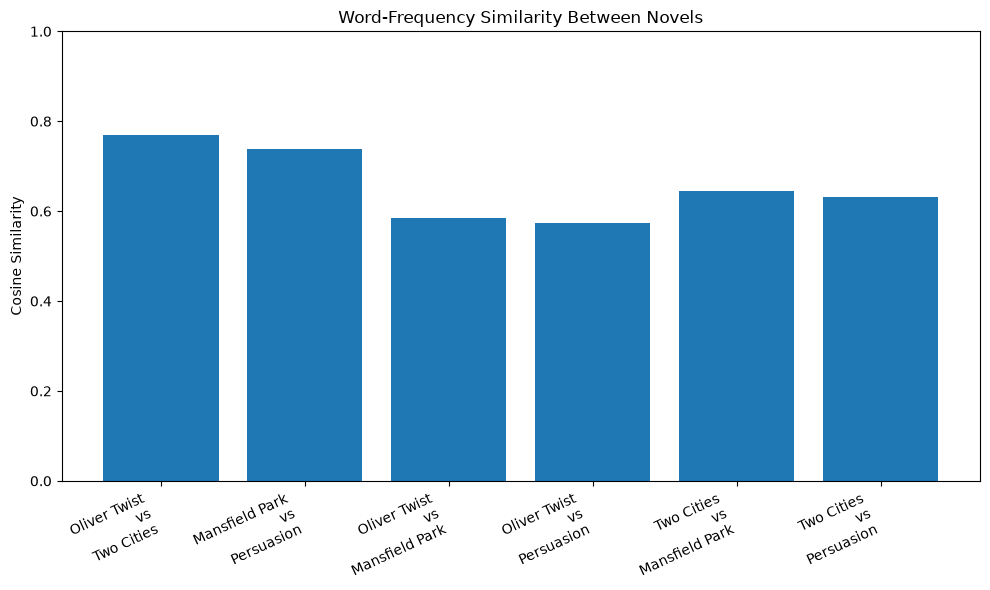

In [16]:
import matplotlib.pyplot as plt

pairs = [
    "Oliver Twist\nvs\nTwo Cities",
    "Mansfield Park\nvs\nPersuasion",
    "Oliver Twist\nvs\nMansfield Park",
    "Oliver Twist\nvs\nPersuasion",
    "Two Cities\nvs\nMansfield Park",
    "Two Cities\nvs\nPersuasion"
]

similarities = [
    0.7697,
    0.7378,
    0.5854,
    0.5740,
    0.6459,
    0.6308
]

plt.figure(figsize=(10, 6))
plt.bar(pairs, similarities)

plt.ylabel("Cosine Similarity")
plt.title("Word-Frequency Similarity Between Novels")
plt.ylim(0, 1)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Same-Author vs. Different-Author Similarity

To summarize the pairwise similarity results, I calculate the average cosine similarity for same-author pairs and different-author pairs.

The average same-author similarity is **0.7538**, compared with **0.6090** for different-author pairs. This provides additional support for the observation that, within this sample, novels written by the same author have more similar word-frequency distributions.

The cosine similarity calculations use the full cleaned vocabulary of each novel, rather than only the most frequent words displayed in the earlier tables and visualizations.

Average same-author similarity: 0.7538
Average different-author similarity: 0.6090


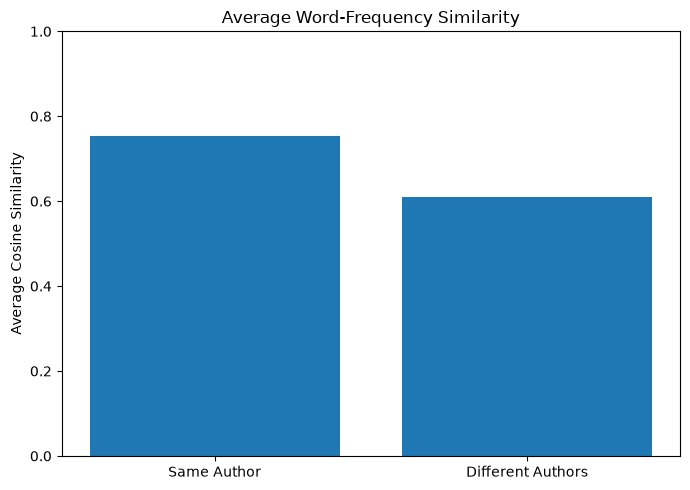

In [17]:
same_author_similarities = [
    0.7697,  # Oliver Twist vs A Tale of Two Cities
    0.7378   # Mansfield Park vs Persuasion
]

different_author_similarities = [
    0.5854,  # Oliver Twist vs Mansfield Park
    0.5740,  # Oliver Twist vs Persuasion
    0.6459,  # A Tale of Two Cities vs Mansfield Park
    0.6308   # A Tale of Two Cities vs Persuasion
]

same_author_avg = sum(same_author_similarities) / len(same_author_similarities)
different_author_avg = (
    sum(different_author_similarities) /
    len(different_author_similarities)
)

print(f"Average same-author similarity: {same_author_avg:.4f}")
print(f"Average different-author similarity: {different_author_avg:.4f}")

plt.figure(figsize=(7, 5))

plt.bar(
    ["Same Author", "Different Authors"],
    [same_author_avg, different_author_avg]
)

plt.ylabel("Average Cosine Similarity")
plt.title("Average Word-Frequency Similarity")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Visualizing Author-Specific Word Usage

The following chart highlights words with some of the largest normalized frequency differences between Dickens and Austen.

Several clear differences appear in the sample. Dickens uses words such as *said*, *upon*, *old*, and *replied* more frequently, while Austen uses words such as *could*, *must*, *would*, *mrs*, and *much* more frequently.

These differences suggest that the two authors have distinct vocabulary patterns across the novels analyzed.

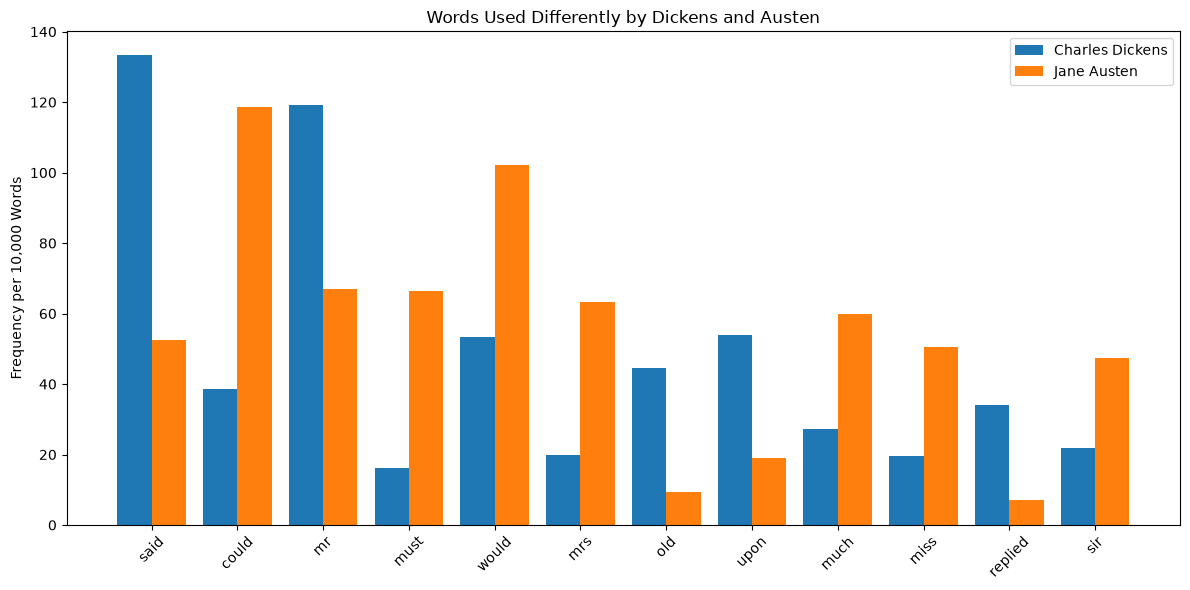

In [18]:
# Select the strongest differences
top_differences = word_differences[:12]

words = [item[0] for item in top_differences]
dickens_values = [item[1] for item in top_differences]
austen_values = [item[2] for item in top_differences]

x = range(len(words))
width = 0.4

plt.figure(figsize=(12, 6))

plt.bar(
    [i - width/2 for i in x],
    dickens_values,
    width,
    label="Charles Dickens"
)

plt.bar(
    [i + width/2 for i in x],
    austen_values,
    width,
    label="Jane Austen"
)

plt.xticks(x, words, rotation=45)
plt.ylabel("Frequency per 10,000 Words")
plt.title("Words Used Differently by Dickens and Austen")
plt.legend()

plt.tight_layout()
plt.show()

## Results and Conclusion

The analysis shows noticeable differences in word usage between Charles Dickens and Jane Austen. Dickens uses words such as *said*, *upon*, and *replied* more frequently, while Austen uses words such as *could*, *must*, *would*, and *think* more frequently.

The cosine similarity analysis also shows that the two same-author pairs have the highest similarity scores:

- *Oliver Twist* vs. *A Tale of Two Cities*: **0.7697**
- *Mansfield Park* vs. *Persuasion*: **0.7378**

All four cross-author comparisons have lower similarity scores, ranging from **0.5740 to 0.6459**.

For this sample, the results support the idea that novels written by the same author have more similar word-frequency patterns than novels written by different authors. However, the dataset contains only two novels from each author, so the results should not be generalized to all works by Dickens or Austen.

A possible extension of this analysis would be to include more novels by each author and test whether the same pattern remains consistent across a larger dataset.